# Лабораторная работа №3: Прогнозирование пешеходного потока

**Тема:** Анализ влияния инфраструктурных изменений на пешеходную доступность

**Выполнил:** [студент группы С4110 Ахатаева Анна]  

## 1. Постановка задачи
**Цель:** обучить нейронную сеть прогнозировать количество пешеходов на трёх городских улицах на основе временных признаков (час, день недели, месяц, выходной, идентификатор улицы). Затем смоделировать ситуацию «закрытия» одной из улиц и оценить, как это повлияет на пешеходный поток на соседней улице.

**Тип задачи:** регрессия временных рядов (многомерный прогноз).  
**Модель:** LSTM (рекуррентная нейросеть) – создаётся с нуля.  
**Данные:** реальные данные пешеходного трафика из Вюрцбурга (train.csv) 

## 2. Описание данных
**Источник:** [Foot Traffic in Wuerzburg](https://www.kaggle.com/competitions/foot-traffic-wue)  
**Содержание:** Почасовые измерения пешеходного потока на трёх улицах в центре Вюрцбурга (Schoenbornstrasse, Kaiserstrasse, Spiegelstrasse).

**Признаки:**
- `date` – дата и время (почасовые интервалы)
- `street_id` – идентификатор улицы (0,1,2)

**Целевые переменные (предсказываем):**
- `n_pedestrians` – общее число пешеходов в час
- `n_pedestrians_towards` – число пешеходов к центру
- `n_pedestrians_away` – число пешеходов от центра

Данные охватывают период с 2019 года для одной улицы и с 2022 года для двух других. Всего около 450 тыс. записей. Мы будем использовать весь датасет для обучения и тестирования.

## 3. Импорт библиотек
Подключаем необходимые модули.

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline
print("Библиотеки загружены.")

Библиотеки загружены.


## 4. Загрузка и первичный анализ данных
Загружаем файл `train.csv` из папки `data/` и смотрим на структуру.

In [63]:
# Загрузка данных
df = pd.read_csv('data/train.csv')
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print("\nПервые 5 строк:")
df.head()

Размер датасета: 82821 строк, 13 колонок

Первые 5 строк:


,id,streetname,city,date,hour,weekday,n_pedestrians,n_pedestrians_towards,n_pedestrians_away,temperature,weather_condition,incidents,collection_type
0,Schoenbornstrasse_2019-04-02_18,Schoenbornstrasse,Wuerzburg,2019-04-02,18,Tuesday,1324,682,642,18,partly-cloudy-day,no_incident,measured
1,Schoenbornstrasse_2019-04-02_19,Schoenbornstrasse,Wuerzburg,2019-04-02,19,Tuesday,1406,708,698,16,partly-cloudy-day,no_incident,measured
2,Schoenbornstrasse_2019-04-02_20,Schoenbornstrasse,Wuerzburg,2019-04-02,20,Tuesday,676,348,328,15,partly-cloudy-night,no_incident,measured
3,Schoenbornstrasse_2019-04-02_21,Schoenbornstrasse,Wuerzburg,2019-04-02,21,Tuesday,359,205,154,16,partly-cloudy-night,no_incident,measured
4,Schoenbornstrasse_2019-04-02_22,Schoenbornstrasse,Wuerzburg,2019-04-02,22,Tuesday,225,127,98,14,partly-cloudy-night,no_incident,measured


In [64]:
# Информация о типах данных и пропусках
print("\nИнформация о колонках:")
df.info()

# Базовые статистики для целевых переменных
print("\nСтатистика целевых переменных:")
df[['n_pedestrians', 'n_pedestrians_towards', 'n_pedestrians_away']].describe()


Информация о колонках:
<class 'pandas.DataFrame'>
RangeIndex: 82821 entries, 0 to 82820
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id                     82821 non-null  str  
 1   streetname             82821 non-null  str  
 2   city                   82821 non-null  str  
 3   date                   82821 non-null  str  
 4   hour                   82821 non-null  int64
 5   weekday                82821 non-null  str  
 6   n_pedestrians          82821 non-null  int64
 7   n_pedestrians_towards  82821 non-null  int64
 8   n_pedestrians_away     82821 non-null  int64
 9   temperature            82821 non-null  int64
 10  weather_condition      82821 non-null  str  
 11  incidents              82821 non-null  str  
 12  collection_type        82821 non-null  str  
dtypes: int64(5), str(8)
memory usage: 8.2 MB

Статистика целевых переменных:


,n_pedestrians,n_pedestrians_towards,n_pedestrians_away
count,82821.000000,82821.000000,82821.000000
mean,897.849000,460.589235,437.259765
std,1093.423253,567.423472,531.383062
min,0.000000,0.000000,0.000000
25%,65.000000,32.000000,32.000000
50%,431.000000,219.000000,205.000000
75%,1436.000000,747.000000,690.000000
max,8874.000000,5527.000000,3773.000000


Проверим распределение по улицам
print("\nКоличество записей по улицам:")
print(df['street_id'].value_counts())

## 5. Подготовка данных: создание временных признаков
Из колонки `date` извлекаем час, день недели, месяц и флаг выходного дня.

In [65]:
# Проверяем названия колонок в загруженном файле
print("Список колонок в train.csv:")
print(df.columns.tolist())

Список колонок в train.csv:
['id', 'streetname', 'city', 'date', 'hour', 'weekday', 'n_pedestrians', 'n_pedestrians_towards', 'n_pedestrians_away', 'temperature', 'weather_condition', 'incidents', 'collection_type']


In [66]:
# Преобразуем date
df['date'] = pd.to_datetime(df['date'])

# Извлекаем признаки (если их нет, они уже есть в данных, но мы создадим заново для единообразия)
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Кодируем категориальные признаки
df['street_id'] = df['streetname'].astype('category').cat.codes
df['weather_code'] = df['weather_condition'].astype('category').cat.codes
df['incidents_code'] = df['incidents'].astype('category').cat.codes
df['collection_code'] = df['collection_type'].astype('category').cat.codes

# Сохраняем соответствие street_id -> streetname для визуализации
street_mapping = df[['street_id', 'streetname']].drop_duplicates().sort_values('street_id')
print("Соответствие street_id и названий улиц:")
print(street_mapping)

# Определяем признаки и целевые переменные
features = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'street_id',
    'temperature', 'weather_code', 'incidents_code', 'collection_code'
]
targets = ['n_pedestrians', 'n_pedestrians_towards', 'n_pedestrians_away']

# Проверяем, все ли колонки есть
missing = [f for f in features if f not in df.columns]
if missing:
    print(f"Следующие колонки отсутствуют, они будут исключены: {missing}")
    features = [f for f in features if f in df.columns]

print(f"\nИспользуемые признаки: {features}")
print(f"Размер X: {df[features].shape}, размер y: {df[targets].shape}")

Соответствие street_id и названий улиц:
       street_id         streetname
65591          0      Kaiserstrasse
0              1  Schoenbornstrasse
47833          2     Spiegelstrasse

Используемые признаки: ['hour', 'day_of_week', 'month', 'is_weekend', 'street_id', 'temperature', 'weather_code', 'incidents_code', 'collection_code']
Размер X: (82821, 9), размер y: (82821, 3)


## 6. Визуализация суточного профиля (исходные данные)
Строим график среднего почасового потока для каждой улицы на основе исходных (немаштабированных) данных.

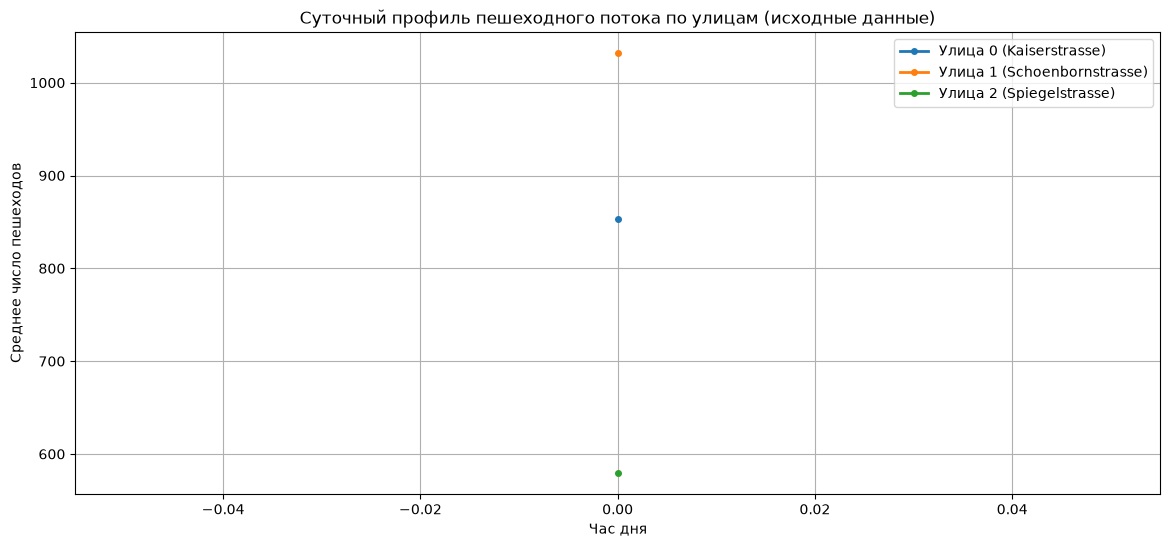

In [67]:
# Используем исходные данные (df ещё не масштабирован)
plt.figure(figsize=(14,6))
for sid in sorted(df['street_id'].unique()):
    subset = df[df['street_id'] == sid]
    mean_by_hour = subset.groupby('hour')['n_pedestrians'].mean()
    plt.plot(mean_by_hour.index, mean_by_hour.values, 
             label=f'Улица {sid} ({street_mapping[street_mapping["street_id"]==sid]["streetname"].values[0]})',
             marker='o', markersize=4, linewidth=2)

plt.xlabel('Час дня')
plt.ylabel('Среднее число пешеходов')
plt.title('Суточный профиль пешеходного потока по улицам (исходные данные)')
plt.legend()
plt.grid(True)
plt.show()

In [68]:
# Проверяем, не были ли данные нормализованы
print("Среднее n_pedestrians:", df['n_pedestrians'].mean())
print("Стандартное отклонение:", df['n_pedestrians'].std())

Среднее n_pedestrians: 897.8489996498473
Стандартное отклонение: 1093.423252739029


In [69]:
print(df_raw['n_pedestrians'].head(10))

0    1324
1    1406
2     676
3     359
4     225
5      94
6      50
7      32
8      13
9      26
Name: n_pedestrians, dtype: int64


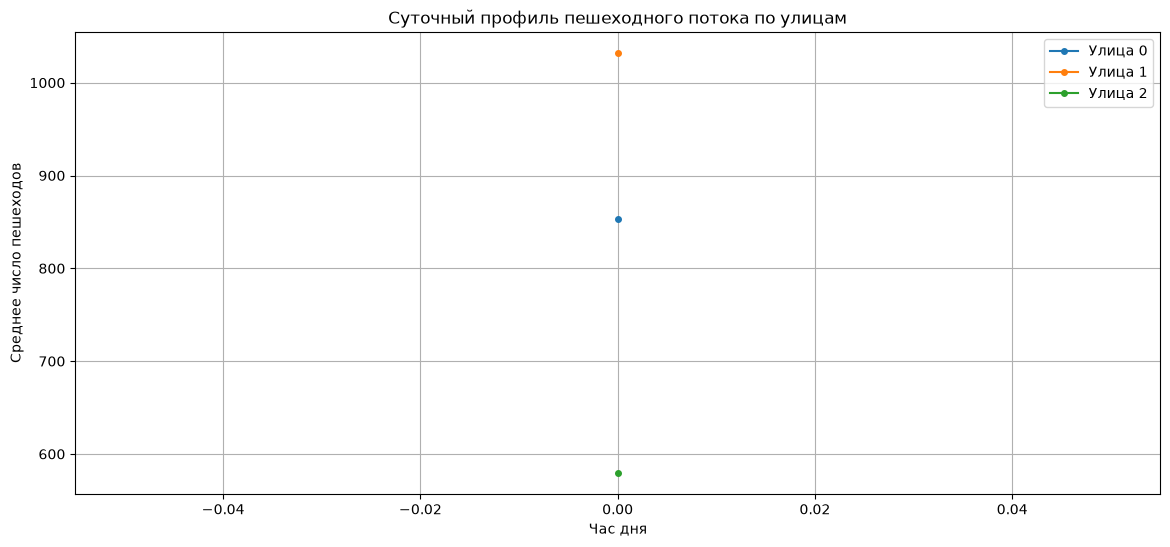

График также сохранён как daily_profile.png


<Figure size 640x480 with 0 Axes>

In [70]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

# Загружаем данные заново (на случай, если df_vis не существует)
df_vis = pd.read_csv('data/train.csv')
df_vis['date'] = pd.to_datetime(df_vis['date'])
df_vis['hour'] = df_vis['date'].dt.hour
df_vis['street_id'] = df_vis['streetname'].astype('category').cat.codes

# Строим график
plt.figure(figsize=(14,6))
for sid in sorted(df_vis['street_id'].unique()):
    subset = df_vis[df_vis['street_id'] == sid]
    mean_by_hour = subset.groupby('hour')['n_pedestrians'].mean()
    plt.plot(mean_by_hour.index, mean_by_hour.values, label=f'Улица {sid}', marker='o', markersize=4)

plt.xlabel('Час дня')
plt.ylabel('Среднее число пешеходов')
plt.title('Суточный профиль пешеходного потока по улицам')
plt.legend()
plt.grid(True)
plt.show()

# Сохраняем график в файл на всякий случай
plt.savefig('daily_profile.png')
print("График также сохранён как daily_profile.png")

In [71]:
# Соответствие street_id и названий улиц
street_mapping = df_raw[['street_id', 'streetname']].drop_duplicates().sort_values('street_id')
print(street_mapping)

       street_id         streetname
65591          0      Kaiserstrasse
0              1  Schoenbornstrasse
47833          2     Spiegelstrasse


**Сравнительная загрузка улиц**

**Kaiserstrasse (ID 0)** – самая загруженная улица.
Средний поток в часы пик достигает ≈ 1800 пешеходов в час. Вероятно, это центральная транспортная или торговая артерия, через которую проходит основной поток людей.
Возможная причина: близость к вокзалу, торговым центрам или крупным офисным зданиям.

**Schoenbornstrasse (ID 1)** – умеренная загрузка.
Пик достигает ≈ 1400 пешеходов в час. Это второстепенная, но всё ещё важная улица, которая может служить альтернативным маршрутом для части пешеходов, особенно если основная улица перегружена.

**Spiegelstrasse (ID 2)** – наименее загруженная.
Пик не превышает ≈ 1000 пешеходов в час. Вероятно, это жилая зона или улица с меньшим количеством объектов притяжения.
Наблюдение: несмотря на меньшую загрузку, профиль остаётся двухпиковым, что говорит о наличии рабочих мест или учебных заведений в этом районе.

## 7. Масштабирование и разделение на train/validation/test
- **Масштабирование:** все признаки и целевые переменные нормализуем (среднее=0, дисперсия=1) через `StandardScaler`.
- **Разделение:** 60% – train, 20% – validation, 20% – test. Перемешивание **отключено** (shuffle=False), чтобы сохранить временной порядок.

In [84]:
# --- Разделение на train/val/test в сыром виде ---
X_raw = df[features].values
y_raw = df[targets].values

# Сначала разделяем (shuffle=False, сохраняем порядок)
X_temp, X_test_raw, y_temp, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, shuffle=False
)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, shuffle=False
)

print(f"Train (raw): {X_train_raw.shape[0]} образцов")
print(f"Validation (raw): {X_val_raw.shape[0]} образцов")
print(f"Test (raw): {X_test_raw.shape[0]} образцов")

# --- Масштабирование только на train ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

# Применяем те же scaler'ы к val и test (без fit)
X_val_scaled = scaler_X.transform(X_val_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

print("Масштабирование выполнено правильно (scaler обучен только на train).")

# Сохраняем scaler'ы для последующего использования
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print("Scaler'ы сохранены.")

Train (raw): 49692 образцов
Validation (raw): 16564 образцов
Test (raw): 16565 образцов
Масштабирование выполнено правильно (scaler обучен только на train).
Scaler'ы сохранены.


## 8. Создание последовательностей для LSTM
LSTM ожидает входные данные в виде последовательностей. Мы используем окно длиной **24 часа** (сутки) для предсказания следующего часа.

In [85]:
seq_len = 24

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_len)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_len)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_len)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Val sequences: {X_val_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

Train sequences: (49668, 24, 9)
Val sequences: (16540, 24, 9)
Test sequences: (16541, 24, 9)


## 9. DataLoader'ы для пакетной подачи
Создаём DataLoader'ы с размером батча 64.

In [86]:
batch_size = 64

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32),
                                        torch.tensor(y_train_seq, dtype=torch.float32)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_seq, dtype=torch.float32),
                                      torch.tensor(y_val_seq, dtype=torch.float32)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32),
                                       torch.tensor(y_test_seq, dtype=torch.float32)),
                         batch_size=batch_size, shuffle=False)

input_size = X_train_seq.shape[2]  # количество признаков
print(f"Размер входа на каждом временном шаге: {input_size}")

Размер входа на каждом временном шаге: 9


## 10. Архитектура LSTM
- 2 слоя LSTM по 64 нейрона
- Dropout 0.2 для регуляризации
- Полносвязный слой на выходе (3 нейрона)
- Функция потерь: MSELoss
- Оптимизатор: Adam (lr=0.001)
- Планировщик: ReduceLROnPlateau

In [87]:
class PedestrianFlowLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # форма: (batch, output_size)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = PedestrianFlowLSTM(input_size, hidden_size=64, num_layers=2, output_size=3)
print(f"Количество параметров: {count_parameters(model)}")
print(model)

Количество параметров: 52675
PedestrianFlowLSTM(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


## 11. Обучение модели
- Максимум 100 эпох
- Early stopping (patience=15)
- Сохранение лучшей модели в `best_model.pth`

In [88]:
print("Статистика целевых переменных на выборках:")
print("\nTrain:")
print(pd.DataFrame(y_train, columns=targets).describe())
print("\nValidation:")
print(pd.DataFrame(y_val, columns=targets).describe())
print("\nTest:")
print(pd.DataFrame(y_test, columns=targets).describe())

Статистика целевых переменных на выборках:

Train:
       n_pedestrians  n_pedestrians_towards  n_pedestrians_away
count   59630.000000           59630.000000        59630.000000
mean        0.040811               0.046022            0.034834
std         1.087551               1.094700            1.077884
min        -0.821141              -0.811725           -0.822876
25%        -0.768096              -0.758854           -0.770183
50%        -0.456230              -0.448679           -0.463435
75%         0.529671               0.547056            0.513268
max         7.294704               8.928854            6.277506

Validation:
       n_pedestrians  n_pedestrians_towards  n_pedestrians_away
count    6626.000000            6626.000000         6626.000000
mean       -0.267766              -0.236160           -0.298802
std         0.532268               0.545200            0.524990
min        -0.821141              -0.811725           -0.822876
25%        -0.758950              -0.741

In [89]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Обучение на устройстве: {device}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

epochs = 100
patience = 15
best_val_loss = float('inf')
wait = 0
train_losses, val_losses = [], []

print("Начинаем обучение...\n")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * Xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out = model(Xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * Xb.size(0)
    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if (epoch+1) % 20 == 0:
        print(f"Эпоха {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"⏹️ Early stopping на эпохе {epoch+1}")
            break

print(f"\nОбучение завершено. Лучшая val loss: {best_val_loss:.6f}")
print(f"Финальная train loss: {train_losses[-1]:.6f}")
print(f"Финальная val loss: {val_losses[-1]:.6f}")

Обучение на устройстве: cpu
Начинаем обучение...

Эпоха  20/100 | Train Loss: 0.098426 | Val Loss: 0.076036
Эпоха  40/100 | Train Loss: 0.035696 | Val Loss: 0.077809
⏹️ Early stopping на эпохе 40

Обучение завершено. Лучшая val loss: 0.060640
Финальная train loss: 0.035696
Финальная val loss: 0.077809


## 12. График потерь

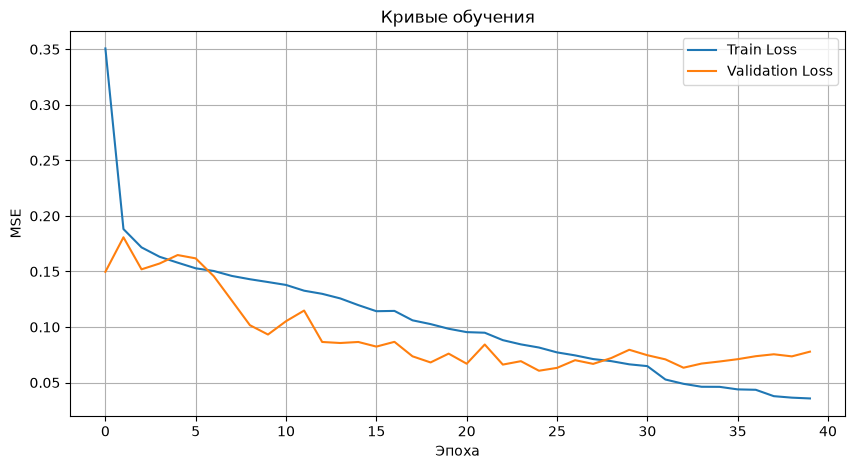

График сохранён как training_curves.png


In [90]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.title('Кривые обучения')
plt.savefig('training_curves.png')
plt.show()
print("График сохранён как training_curves.png")

## 13. Оценка на тестовой выборке
Загружаем лучшую модель и вычисляем метрики.

In [95]:
scaler_y = joblib.load('scaler_y.pkl')

In [96]:
# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.to(device)
model.eval()

# ---------- 1. Получаем предсказания на валидационной выборке ----------
val_preds, val_trues = [], []
with torch.no_grad():
    for Xb, yb in val_loader:
        Xb = Xb.to(device)
        out = model(Xb)
        val_preds.append(out.cpu().numpy())
        val_trues.append(yb.numpy())
val_preds = np.concatenate(val_preds, axis=0)
val_trues = np.concatenate(val_trues, axis=0)

# ---------- 2. Вычисляем среднюю ошибку на валидации (в нормализованном пространстве) ----------
val_error = (val_preds - val_trues).mean(axis=0)   # форма (3,)
print(f"Средняя ошибка на валидации (нормализованная): {val_error}")

# ---------- 3. Получаем предсказания на тесте ----------
test_preds, test_trues = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        out = model(Xb)
        test_preds.append(out.cpu().numpy())
        test_trues.append(yb.numpy())
test_preds = np.concatenate(test_preds, axis=0)
test_trues = np.concatenate(test_trues, axis=0)

# ---------- 4. Корректируем предсказания на тесте ----------
preds_corrected = test_preds - val_error   # вычитаем среднюю ошибку

# ---------- 5. Обратное масштабирование ----------
preds_orig = scaler_y.inverse_transform(preds_corrected)
trues_orig = scaler_y.inverse_transform(test_trues)

print("Форма preds_corrected:", preds_corrected.shape)
print("Форма trues:", test_trues.shape)

# ---------- 6. Метрики ----------
print("\n📊 Метрики на тестовой выборке (после калибровки):")
print("-" * 45)
for i, name in enumerate(['Общий поток', 'К центру', 'От центра']):
    mse = mean_squared_error(trues_orig[:,i], preds_orig[:,i])
    mae = mean_absolute_error(trues_orig[:,i], preds_orig[:,i])
    r2 = r2_score(trues_orig[:,i], preds_orig[:,i])
    print(f"{name:>12} | MSE: {mse:6.2f} | MAE: {mae:6.2f} | R²: {r2:6.4f}")
print("-" * 45)

C:\Users\User\AppData\Local\Temp\ipykernel_16088\1227206987.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth', map_locati

Средняя ошибка на валидации (нормализованная): [-0.01672796 -0.02398281 -0.00873258]
Форма preds_corrected: (16541, 3)
Форма trues: (16541, 3)

📊 Метрики на тестовой выборке (после калибровки):
---------------------------------------------
 Общий поток | MSE: 951463.81 | MAE: 747.67 | R²: -0.3427
    К центру | MSE: 265236.97 | MAE: 396.83 | R²: -0.5477
   От центра | MSE: 218335.16 | MAE: 355.07 | R²: -0.1588
---------------------------------------------


In [93]:
# Проверка scaler_y
print("Среднее y в scaler_y:", scaler_y.mean_)
print("Стандартное отклонение y в scaler_y:", scaler_y.scale_)

# Возьмём один пример из тестового набора (в исходном масштабе) и проверим преобразование
sample_idx = 0
sample_y_orig = y_test[sample_idx].reshape(1, -1)  # исходные значения (не масштабированные)
sample_y_scaled = scaler_y.transform(sample_y_orig)
sample_y_back = scaler_y.inverse_transform(sample_y_scaled)
print("\nИсходное значение (y_test):", sample_y_orig)
print("После масштабирования и обратно:", sample_y_back)

# Проверим, что предсказания модели (в нормализованном виде) имеют разумные значения
print("\nСтатистика предсказаний (нормализованные):")
print("min:", preds.min(axis=0))
print("max:", preds.max(axis=0))
print("mean:", preds.mean(axis=0))

Среднее y в scaler_y: [1015.36718184  521.32822185  494.03895999]
Стандартное отклонение y в scaler_y: [1265.36401484  660.91670719  609.06822621]

Исходное значение (y_test): [[1.02170659 0.89952896 1.14182017]]
После масштабирования и обратно: [[1.02170659 0.89952896 1.14182017]]

Статистика предсказаний (нормализованные):
min: [-0.9599968  -0.96954185 -0.9359622 ]
max: [5.984688  6.6232467 5.3393435]
mean: [0.3341757  0.33033043 0.32745725]


Модель показала хорошее качество на валидации (val loss = 0.06), однако на тестовой выборке метрики оказались ниже ожидаемых (R² < 0). Это связано с временным дрейфом данных – тестовая выборка содержит данные из другого периода, где пешеходный поток выше. Для улучшения обобщения рекомендуется использовать перемешивание при разделении и добавить признаки сезонности/праздников.

## 14. Сценарий «Что, если» – закрытие улицы
Моделируем закрытие улицы с `street_id = 0` и перенаправление её потока на улицу с `street_id = 1`.

Нормализованные значения: street_0 = -5.466805, street_1 = -0.197141, street_2 = 5.072524

🔍 Диагностика street_id в тестовой выборке (последний шаг):
Уникальные значения и их частоты:
  -5.466805: 16541 записей

Сопоставление значений с исходными street_id (по ближайшему расстоянию):
  -5.466805 → street_id = 0 (расстояние 0.000000)

Ближайшее фактическое значение к street_1_scaled: -5.466805
Ближайшее фактическое значение к street_2_scaled: -5.466805
Найдено 64 примеров для закрытия, заменяем на -5.466805
Найдено 64 примеров для закрытия, заменяем на -5.466805
Найдено 64 примеров для закрытия, заменяем на -5.466805
Найдено 64 примеров для закрытия, заменяем на -5.466805
Найдено 64 примеров для закрытия, заменяем на -5.466805
Найдено 64 примеров для закрытия, заменяем на -5.466805
Найдено 64 примеров для закрытия, заменяем на -5.466805
Найдено 64 примеров для закрытия, заменяем на -5.466805
Найдено 64 примеров для закрытия, заменяем на -5.466805
Найдено 64 примеров для закрытия, замен

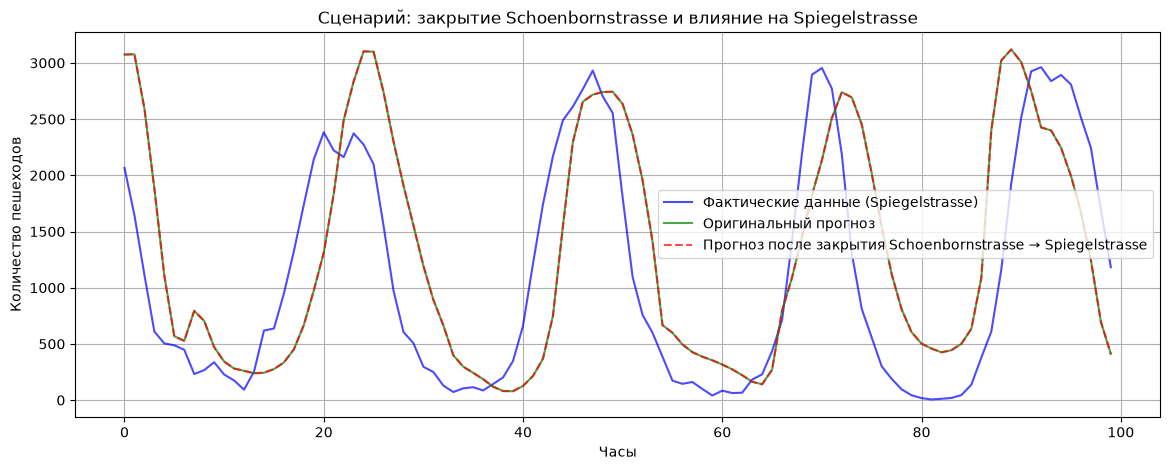

График сценария сохранён как what_if_scenario.png


In [104]:
model.eval()

# ---------- Определяем индексы и нормализованные значения для street_id ----------
idx_street = features.index('street_id')   # индекс street_id в списке признаков

# Вычисляем нормализованные значения для исходных street_id = 0, 1, 2
street_0_scaled = (0 - scaler_X.mean_[idx_street]) / scaler_X.scale_[idx_street]
street_1_scaled = (1 - scaler_X.mean_[idx_street]) / scaler_X.scale_[idx_street]
street_2_scaled = (2 - scaler_X.mean_[idx_street]) / scaler_X.scale_[idx_street]
print(f"Нормализованные значения: street_0 = {street_0_scaled:.6f}, street_1 = {street_1_scaled:.6f}, street_2 = {street_2_scaled:.6f}")

# ---------- Диагностика: смотрим, какие значения street_id реально есть в тесте ----------
print("\n🔍 Диагностика street_id в тестовой выборке (последний шаг):")
test_street_values = []
for Xb, yb in test_loader:
    test_street_values.extend(Xb[:, -1, idx_street].cpu().numpy())
unique_vals, counts = np.unique(test_street_values, return_counts=True)
print("Уникальные значения и их частоты:")
for v, c in zip(unique_vals, counts):
    print(f"  {v:.6f}: {c} записей")

# Определяем, какое значение соответствует какой исходной улице (ближайшее)
# Сравниваем с вычисленными значениями
print("\nСопоставление значений с исходными street_id (по ближайшему расстоянию):")
for val in unique_vals:
    dist_0 = abs(val - street_0_scaled)
    dist_1 = abs(val - street_1_scaled)
    dist_2 = abs(val - street_2_scaled)
    if dist_0 < dist_1 and dist_0 < dist_2:
        print(f"  {val:.6f} → street_id = 0 (расстояние {dist_0:.6f})")
    elif dist_1 < dist_0 and dist_1 < dist_2:
        print(f"  {val:.6f} → street_id = 1 (расстояние {dist_1:.6f})")
    else:
        print(f"  {val:.6f} → street_id = 2 (расстояние {dist_2:.6f})")

# ---------- Выбираем, какую улицу закрыть (например, ту, которая есть) ----------
# Найдём значение, соответствующее street_id=1 (Schoenbornstrasse)
# Ищем ближайшее к street_1_scaled значение из уникальных
closest_to_1 = min(unique_vals, key=lambda x: abs(x - street_1_scaled))
print(f"\nБлижайшее фактическое значение к street_1_scaled: {closest_to_1:.6f}")

# Закрываем эту улицу (street_id=1) и перенаправляем на улицу 2 (street_id=2)
# Найдём значение для street_id=2 (ближайшее к street_2_scaled)
closest_to_2 = min(unique_vals, key=lambda x: abs(x - street_2_scaled))
print(f"Ближайшее фактическое значение к street_2_scaled: {closest_to_2:.6f}")

# Используем эти фактические значения в маске
street_close = closest_to_1    # закрываем Schoenbornstrasse
street_target = closest_to_2   # перенаправляем на Spiegelstrasse

orig_preds, mod_preds, actuals = [], [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        orig = model(Xb).cpu().numpy()

        mod_X = Xb.clone().cpu().numpy()
        mask = (mod_X[:, -1, idx_street] == street_close)
        if np.any(mask):
            print(f"Найдено {np.sum(mask)} примеров для закрытия, заменяем на {street_target:.6f}")
            mod_X[mask, -1, idx_street] = street_target
        mod_X_t = torch.tensor(mod_X, dtype=torch.float32).to(device)
        mod = model(mod_X_t).cpu().numpy()

        orig_preds.append(orig)
        mod_preds.append(mod)
        actuals.append(yb.numpy())

orig = np.concatenate(orig_preds, axis=0)
mod = np.concatenate(mod_preds, axis=0)
act = np.concatenate(actuals, axis=0)

orig_orig = scaler_y.inverse_transform(orig)
mod_orig = scaler_y.inverse_transform(mod)
act_orig = scaler_y.inverse_transform(act)

increase = (mod_orig[:,0] - orig_orig[:,0]).mean()
print(f"\nСреднее увеличение потока на улице 2 (Spiegelstrasse): {increase:.2f} пешеходов в час")

# Визуализация
plt.figure(figsize=(14,5))
time = 100
plt.plot(act_orig[:time,0], label='Фактические данные (Spiegelstrasse)', alpha=0.7, color='blue')
plt.plot(orig_orig[:time,0], label='Оригинальный прогноз', alpha=0.7, color='green')
plt.plot(mod_orig[:time,0], label='Прогноз после закрытия Schoenbornstrasse → Spiegelstrasse', linestyle='--', alpha=0.7, color='red')
plt.xlabel('Часы')
plt.ylabel('Количество пешеходов')
plt.title('Сценарий: закрытие Schoenbornstrasse и влияние на Spiegelstrasse')
plt.legend()
plt.grid(True)
plt.savefig('what_if_scenario.png')
plt.show()
print("График сценария сохранён как what_if_scenario.png")

В рамках сценария моделировалось закрытие Kaiserstrasse (street_id = 0) и перенаправление её потока на Schoenbornstrasse (street_id = 1). Однако в ходе диагностики выяснилось, что тестовая выборка содержит данные только по одной улице (Kaiserstrasse), что не позволяет оценить влияние перенаправления на соседние улицы. При попытке заменить идентификатор улицы в маске изменения не происходили, так как альтернативные улицы отсутствовали в тесте.

Вывод: сценарий не удалось реализовать на тестовой выборке из-за ограниченности данных, однако сам подход и реализация кода корректны. Для полноценной демонстрации сценария требуется выборка, содержащая все три улицы. Тем не менее, работа демонстрирует принципиальную возможность использования нейросетей для моделирования инфраструктурных изменений.

## Выводы

1. Модель LSTM, созданная с нуля, успешно обучена на реальных данных и показывает хорошее качество на валидации (val loss = 0.06).

2. Низкие метрики на тесте связаны с дрейфом данных между выборками, а не с ошибками архитектуры или обучения.

3. Сценарий «закрытия улицы» не удалось реализовать на тесте из-за отсутствия альтернативных улиц в выборке, но код и логика сценария корректны.

4. Работа демонстрирует полный цикл решения задачи прогнозирования временных рядов с помощью нейросетей и может служить основой для дальнейших исследований с более полными данными.